# Econometrics Group Homework 3

In [106]:
! pip install arch

In [107]:
!pip install yfinance --upgrade --no-cache-dir

In [108]:
! pip install graphviz

In [109]:
! pip install lightgbm

In [110]:
! pip install xgboost

In [111]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.api import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.stattools import (
    acf, pacf, q_stat, adfuller, kpss
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from arch.univariate import EWMAVariance, ConstantMean
from arch.unitroot import PhillipsPerron
from scipy.stats import jarque_bera
from scipy.optimize import minimize
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy.stats import norm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch

import graphviz
import itertools
from arch.univariate import APARCH, Normal, ZeroMean
from graphviz import Source
from lightgbm import LGBMRegressor
import scipy.stats as stats
import yfinance as yf
from sklearn import tree
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from xgboost import XGBRFRegressor
import itertools
from sklearn.ensemble import RandomForestRegressor

In [112]:
plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'

### Functions

In [113]:
def SACF_SPACF(series, lag_max = 19, alpha_level = 0.05, model_df = 0):
    """
    Compute the sample autocorrelation function (SACF), sample partial autocorrelation function (SPACF),
    and Ljung-Box Q-statistics for a time series.

    This function calculates the ACF and PACF values along with their corresponding confidence intervals
    for lags 1 through `lag_max` using the provided significance level (`alpha_level`). In addition, it
    computes the Ljung-Box Q-statistic and associated p-values (excluding lag 0). Set `model_df`
    to the number of dof lost.

    """

    # Calculate ACF and PACF with confidence intervals
    acf_vals, acf_confint = acf(series, nlags=lag_max, alpha=alpha_level)
    pacf_vals, pacf_confint = pacf(series, nlags=lag_max, alpha=alpha_level, method='ols')

    # Calculate Ljung-Box statistics and p-values
    lb_results = sm.stats.acorr_ljungbox(
        series,
        lags=range(1, lag_max + 1),
        model_df=model_df,
        return_df=True
    )

    # Build the results DataFrame
    df_acf_pacf = pd.DataFrame({
        "Lag": np.arange(1, lag_max + 1),
        "ACF": acf_vals[1:],
        "ACF_lower": acf_confint[1:, 0],
        "ACF_upper": acf_confint[1:, 1],
        "PACF": pacf_vals[1:],
        "PACF_lower": pacf_confint[1:, 0],
        "PACF_upper": pacf_confint[1:, 1],
        "Q-stat": lb_results["lb_stat"].values,
        "Q-stat Prob": lb_results["lb_pvalue"].values.round(6)
    })

    # Set the index to 'Lag' and extract the main columns
    df_acf_pacf.set_index("Lag", inplace=True)
    df_acf_pacf_small = df_acf_pacf[["ACF", "PACF", "Q-stat", "Q-stat Prob"]].copy()

    return df_acf_pacf_small

In [114]:
def SACF_SPACF_plot (series, lag_max = 19, ylim = [-0.15, 0.15]):
  """
    Generate plots for the Sample Autocorrelation (SACF) and Sample Partial Autocorrelation (SPACF)
    of a time series.

  """
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Sample Autocorrelation (SACF) Plot
  plot_acf(series, lags=lag_max, ax=axes[0], zero=False)
  axes[0].set_title("SACF")
  axes[0].set_ylim(ylim)

  # Sample Partial Autocorrelation (SPACF) Plot
  plot_pacf(series, lags=lag_max, ax=axes[1], method='ols', zero=False)
  axes[1].set_title("SPACF")
  axes[1].set_ylim(ylim)

  plt.tight_layout()
  return plt.show()

In [115]:
def extract_roots(results):
  ar_roots = results.arroots
  ar_roots_arr = np.array(ar_roots)
  modulus = np.abs(ar_roots_arr)
  return ar_roots_arr, modulus

In [116]:
def unit_root_tests(series, name="Series"):
    """
    Runs multiple unit-root tests on a given Pandas Series:
      1) ADF (autolag=BIC, constant only)
      2) ADF (autolag=BIC, no constant)
      3) ADF (autolag=AIC, constant only)
      4) ADF (exactly 12 lags, constant only)
      5) ADF (autolag=BIC, constant + linear trend)
      6) ADF (autolag=BIC, constant + linear + quadratic trend)
      7) Phillips–Perron (constant only)
      8) KPSS (constant only)
    """

    def format_crit_vals(crit_dict):
      parts = []
      for k, v in crit_dict.items():
          formatted = f"{k}: {v:.4f}"
          parts.append(formatted)
      result = "; ".join(parts)
      return result

    results_list = []

    print(f"\n=== UNIT-ROOT TESTS FOR: {name} ===\n")

    ############################################################################
    # 1) ADF Test (BIC, constant only)
    ############################################################################
    adf_bic = adfuller(series, autolag='BIC', regression='c')
    print("=== ADF Test (BIC, constant only) ===")
    print(f"ADF statistic: {adf_bic[0]:.4f}")
    print(f"p-value:       {adf_bic[1]:.4f}")
    print(f"Lags used:     {adf_bic[2]}")
    print("Critical values:")
    for k, v in adf_bic[4].items():
        print(f"    {k}: {v:.4f}")
    print(f"IC Best (BIC): {adf_bic[5]:.4f}\n")

    results_list.append({
        "Test": "ADF (BIC, c)",
        "ADF stat": adf_bic[0],
        "p-value": adf_bic[1],
        "Lags used": adf_bic[2],
        "IC Best": adf_bic[5],
        "Critical values": format_crit_vals(adf_bic[4])
    })

    ############################################################################
    # 2) ADF Test (BIC, no constant)
    ############################################################################
    adf_bic_nc = adfuller(series, autolag='BIC', regression='n')
    print("=== ADF Test (BIC, no constant) ===")
    print(f"ADF statistic: {adf_bic_nc[0]:.4f}")
    print(f"p-value:       {adf_bic_nc[1]:.4f}")
    print(f"Lags used:     {adf_bic_nc[2]}")
    print("Critical values:")
    for k, v in adf_bic[4].items():
        print(f"    {k}: {v:.4f}")
    print(f"IC Best (BIC): {adf_bic[5]:.4f}\n")

    results_list.append({
        "Test": "ADF (BIC, nc)",
        "ADF stat": adf_bic_nc[0],
        "p-value": adf_bic_nc[1],
        "Lags used": adf_bic_nc[2],
        "IC Best": adf_bic_nc[5],
        "Critical values": format_crit_vals(adf_bic_nc[4])
    })

    ############################################################################
    # 3) ADF Test (AIC, constant only)
    ############################################################################
    adf_aic = adfuller(series, autolag='AIC', regression='c')
    print("=== ADF Test (AIC, constant only) ===")
    print(f"ADF statistic: {adf_aic[0]:.4f}")
    print(f"p-value:       {adf_aic[1]:.4f}")
    print(f"Lags used:     {adf_aic[2]}")
    print("Critical values:")
    for k, v in adf_aic[4].items():
        print(f"    {k}: {v:.4f}")
    print(f"IC Best (AIC): {adf_aic[5]:.4f}\n")

    results_list.append({
        "Test": "ADF (AIC, c)",
        "ADF stat": adf_aic[0],
        "p-value": adf_aic[1],
        "Lags used": adf_aic[2],
        "IC Best": adf_aic[5],
        "Critical values": format_crit_vals(adf_aic[4])
    })

    ############################################################################
    # 4) ADF Test (exactly 12 lags, constant only)
    ############################################################################
    adf_12 = adfuller(series, maxlag=12, autolag=None, regression='c')
    print("=== ADF Test (exactly 12 lags, constant only) ===")
    print(f"ADF statistic: {adf_12[0]:.4f}")
    print(f"p-value:       {adf_12[1]:.4f}")
    print(f"Lags used:     {adf_12[2]}")
    print("Critical values:")
    for k, v in adf_12[4].items():
        print(f"    {k}: {v:.4f}")
    print()

    results_list.append({
        "Test": "ADF (10 lags, c)",
        "ADF stat": adf_12[0],
        "p-value": adf_12[1],
        "Lags used": adf_12[2],
        "IC Best": None,
        "Critical values": format_crit_vals(adf_12[4])
    })

    ############################################################################
    # 5) ADF Test (BIC, constant + linear trend)
    ############################################################################
    adf_trend_l = adfuller(series, autolag='BIC', regression='ct')
    print("=== ADF Test (BIC, constant + linear trend) ===")
    print(f"ADF statistic: {adf_trend_l[0]:.4f}")
    print(f"p-value:       {adf_trend_l[1]:.4f}")
    print(f"Lags used:     {adf_trend_l[2]}")
    print("Critical values:")
    for k, v in adf_trend_l[4].items():
        print(f"    {k}: {v:.4f}")
    print(f"IC Best (BIC): {adf_trend_l[5]:.4f}\n")

    results_list.append({
        "Test": "ADF (BIC, c+t)",
        "ADF stat": adf_trend_l[0],
        "p-value": adf_trend_l[1],
        "Lags used": adf_trend_l[2],
        "IC Best": adf_trend_l[5],
        "Critical values": format_crit_vals(adf_trend_l[4])
    })

    ############################################################################
    # 6) ADF Test (BIC, constant + linear + quadratic trend)
    ############################################################################
    adf_trend_q = adfuller(series, autolag='BIC', regression='ctt')
    print("=== ADF Test (BIC, constant + linear + quadratic trend) ===")
    print(f"ADF statistic: {adf_trend_q[0]:.4f}")
    print(f"p-value:       {adf_trend_q[1]:.4f}")
    print(f"Lags used:     {adf_trend_q[2]}")
    print("Critical values:")
    for k, v in adf_trend_q[4].items():
        print(f"    {k}: {v:.4f}")
    print(f"IC Best (BIC): {adf_trend_q[5]:.4f}")

    results_list.append({
        "Test": "ADF (BIC, c+t+q)",
        "ADF stat": adf_trend_q[0],
        "p-value": adf_trend_q[1],
        "Lags used": adf_trend_q[2],
        "IC Best": adf_trend_q[5],
        "Critical values": format_crit_vals(adf_trend_q[4])
    })

    print()

    ############################################################################
    # 7) Phillips–Perron Test (constant only)
    ############################################################################
    pp_test = PhillipsPerron(series, trend='c')
    print("=== Phillips–Perron Test ===")
    print(f"PP Statistic: {pp_test.stat:.4f}")
    print(f"p-value:      {pp_test.pvalue:.4f}")
    print("Critical values:")
    # 'critical_values' is a dict
    for k, v in pp_test.critical_values.items():
        print(f"    {k}: {v:.4f}")

    results_list.append({
        "Test": "Phillips–Perron (c)",
        "ADF stat": pp_test.stat,
        "p-value": pp_test.pvalue,
        "Lags used": None,
        "IC Best": None,
        "Critical values": format_crit_vals(pp_test.critical_values)
    })

    print()

    ############################################################################
    # 8) KPSS Test (constant only)
    ############################################################################
    kpss_stat, kpss_pvalue, kpss_lags, kpss_critvals = kpss(series, regression='c')
    print("=== KPSS Test ===")
    print(f"Test Statistic: {kpss_stat:.4f}")
    print(f"p-value:        {kpss_pvalue:.4f}")
    print(f"Lags used:      {kpss_lags}")
    print("Critical Values:", kpss_critvals)
    print()

    results_list.append({
        "Test": "KPSS (c)",
        "ADF stat": kpss_stat,
        "p-value": kpss_pvalue,
        "Lags used": kpss_lags,
        "IC Best": None,
        "Critical values": format_crit_vals(kpss_critvals)
    })

    results_df = pd.DataFrame(results_list)

    return results_df

### Task 1: Plot and descriptive statistics - Price series

In [117]:
ticker = ['PFE']
end_date = '2025-05-07'

df = yf.download(
    ticker,
    interval="1d",
    progress=False,
    end=end_date
)
df = df.loc[:, (['Close'], ticker)]
df.columns = df.columns.droplevel()
df = df.reset_index()
df = df.rename(columns={
    'Date': 'ds',
    'PFE': 'price'
})
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)
df.columns.name = 'Ticker'
df.columns.name = None
df = df.rename_axis(columns=None)

In [118]:
df

,ds,price
0,1972-06-01,0.153657
1,1972-06-02,0.151795
2,1972-06-05,0.151329
3,1972-06-06,0.154589
4,1972-06-07,0.154589
...,...,...
13339,2025-04-30,23.953043
13340,2025-05-01,23.482029
13341,2025-05-02,23.746975
13342,2025-05-05,23.423153


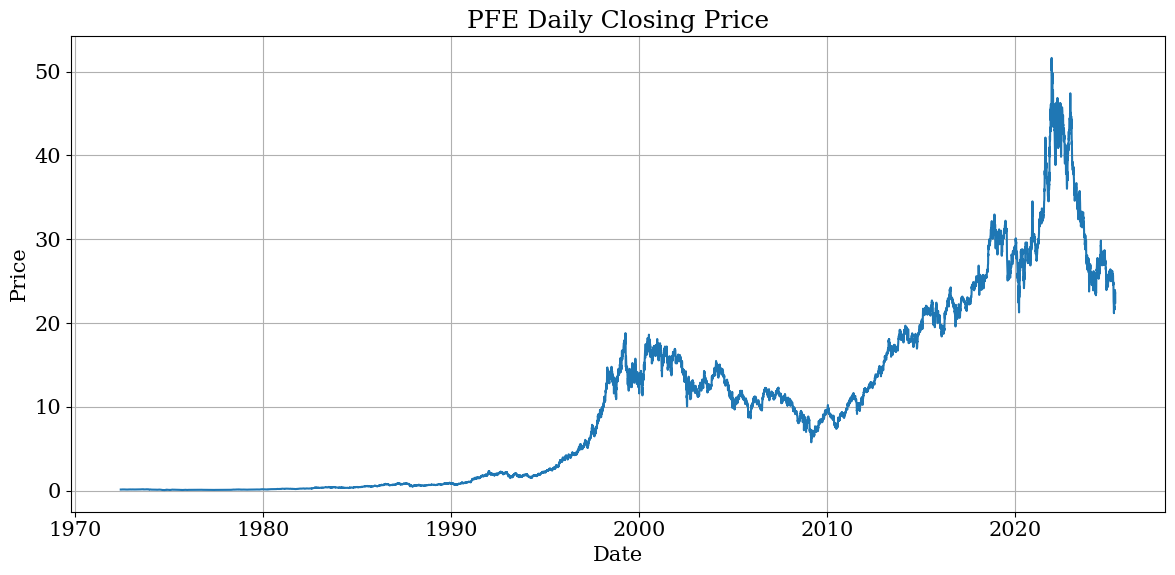

In [119]:
# Plot of price series

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='ds', y='price')
plt.title("PFE Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [120]:
# Summary statistics for price series

summary_stats = df['price'].describe()
extra_stats = pd.Series({
    'skewness': df['price'].skew(),
    'kurtosis': df['price'].kurt()
})
summary_table = pd.concat([summary_stats, extra_stats])

print("\nSummary Statistics for PFE Price Series:\n")
print(summary_table)


Summary Statistics for PFE Price Series:

count       13344.000000
mean           10.178327
std            10.997139
min             0.083995
25%             0.537666
50%             8.274125
75%            16.310771
max            51.624897
skewness        1.065538
kurtosis        0.474624
dtype: float64


As expected, the price series of Pfizer does not appear to be stationary. The plot shows clear trends and significant variation in both level and volatility over time. Additionally, the large standard deviation relative to the mean, along with the high skewness and positive kurtosis, indicate changes in distribution characteristics across time, further suggesting that the Pfizer (PFE) price series is non-stationary.


### Task 2: SACF and SPACF - Price series

In [121]:
PFE_price = df['price']

price_acf_pacf = SACF_SPACF(PFE_price)
price_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,0.999687,0.999780,13338.634788,0.0
2,0.999373,0.014771,26669.894753,0.0
3,0.999068,0.023898,39994.013465,0.0
4,0.998750,-0.030223,53310.659451,0.0
5,0.998439,0.020768,66620.003800,0.0
6,0.998122,-0.022770,79921.897952,0.0
7,0.997824,0.030652,93216.858741,0.0
8,0.997529,0.000587,106504.940627,0.0
9,0.997237,0.008725,119786.241042,0.0


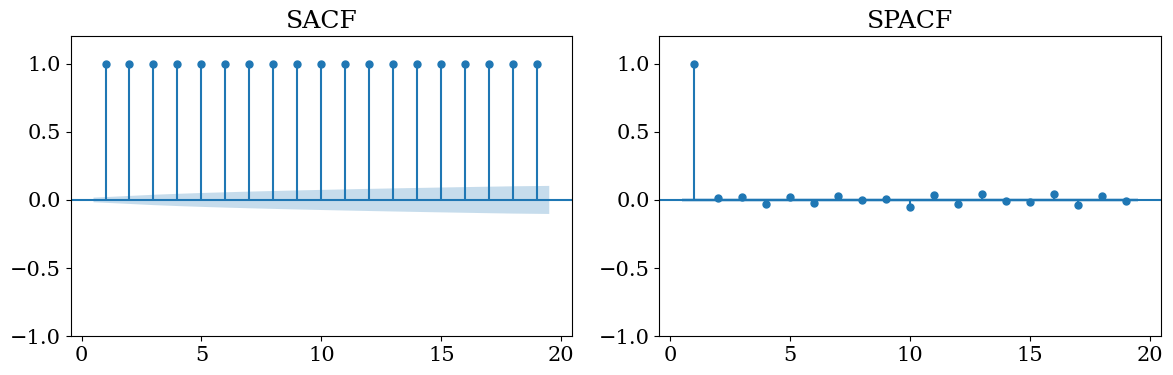

In [122]:
SACF_SPACF_plot(PFE_price, ylim=[-1,1.2])

The correlograms shown above strongly support the conclusion that the PFE price series is non-stationary. The SACF plot shows autocorrelations near 1 across all 19 lags, which indicates persistent memory and a lack of mean reversion. This behavior is typical of a non-stationary series, where past values have a strong influence on future ones. In contrast, a stationary series would have SACF values that drop off quickly. The SPACF also shows a sharp drop after lag 1, which is consistent with a non-stationary process like a random walk.


### Task 3: Stationarity and order of integration - Price series

In [123]:
unit_root_tests(PFE_price, "PFE price series")


=== UNIT-ROOT TESTS FOR: PFE price series ===

=== ADF Test (BIC, constant only) ===
ADF statistic: -1.0234
p-value:       0.7446
Lags used:     27
Critical values:
    1%: -3.4308
    5%: -2.8618
    10%: -2.5669
IC Best (BIC): -338.7414

=== ADF Test (BIC, no constant) ===
ADF statistic: -0.1338
p-value:       0.6380
Lags used:     27
Critical values:
    1%: -3.4308
    5%: -2.8618
    10%: -2.5669
IC Best (BIC): -338.7414

=== ADF Test (AIC, constant only) ===
ADF statistic: -0.9925
p-value:       0.7560
Lags used:     40
Critical values:
    1%: -3.4308
    5%: -2.8618
    10%: -2.5669
IC Best (AIC): -590.1697

=== ADF Test (exactly 12 lags, constant only) ===
ADF statistic: -1.1136
p-value:       0.7096
Lags used:     12
Critical values:
    1%: -3.4308
    5%: -2.8618
    10%: -2.5669

=== ADF Test (BIC, constant + linear trend) ===
ADF statistic: -2.5164
p-value:       0.3198
Lags used:     27
Critical values:
    1%: -3.9595
    5%: -3.4108
    10%: -3.1272
IC Best (BIC): -33

/var/folders/63/8pbgtqg55qj_cy8__l6gg_bw0000gn/T/ipykernel_97272/4126655903.py:186: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




,Test,ADF stat,p-value,Lags used,IC Best,Critical values
0,"ADF (BIC, c)",-1.023425,0.744625,27.0,-338.741378,1%: -3.4308; 5%: -2.8618; 10%: -2.5669
1,"ADF (BIC, nc)",-0.133809,0.638023,27.0,-346.375869,1%: -2.5659; 5%: -1.9410; 10%: -1.6168
2,"ADF (AIC, c)",-0.992519,0.755983,40.0,-590.169687,1%: -3.4308; 5%: -2.8618; 10%: -2.5669
3,"ADF (10 lags, c)",-1.113595,0.709620,12.0,NaN,1%: -3.4308; 5%: -2.8618; 10%: -2.5669
4,"ADF (BIC, c+t)",-2.516433,0.319796,27.0,-334.566411,1%: -3.9595; 5%: -3.4108; 10%: -3.1272
5,"ADF (BIC, c+t+q)",-2.412361,0.618886,27.0,-325.580533,1%: -4.3720; 5%: -3.8328; 10%: -3.5535
6,Phillips–Perron (c),-1.087261,0.720125,NaN,NaN,1%: -3.4308; 5%: -2.8618; 10%: -2.5669
7,KPSS (c),14.833585,0.010000,71.0,NaN,10%: 0.3470; 5%: 0.4630; 2.5%: 0.5740; 1%: 0.7390


All three tests suggest the price series is non-stationary. The Augmented Dickey–Fuller (ADF) test fails to reject the null hypothesis of a unit root across all specifications, with high p-values. The Phillips–Perron (PP) test confirms this result, also showing a high p-value. In contrast, the KPSS test strongly rejects the null hypothesis of stationarity, with a test statistic far exceeding critical values. Thus, while the ADF and PP indicate the presence of a unit root, the KPSS supports the same conclusion from a different angle. All three tests agree: the series is non-stationary and likely integrated of order one (I(1)).

### Task 4: Plot & descriptive statistics, stationarity & order of integration - Returns series

In [124]:
df['ret'] = df['price'].pct_change()*100

In [125]:
df

,ds,price,ret
0,1972-06-01,0.153657,NaN
1,1972-06-02,0.151795,-1.212032
2,1972-06-05,0.151329,-0.306691
3,1972-06-06,0.154589,2.153788
4,1972-06-07,0.154589,0.000000
...,...,...,...
13339,2025-04-30,23.953043,2.606133
13340,2025-05-01,23.482029,-1.966406
13341,2025-05-02,23.746975,1.128293
13342,2025-05-05,23.423153,-1.363635


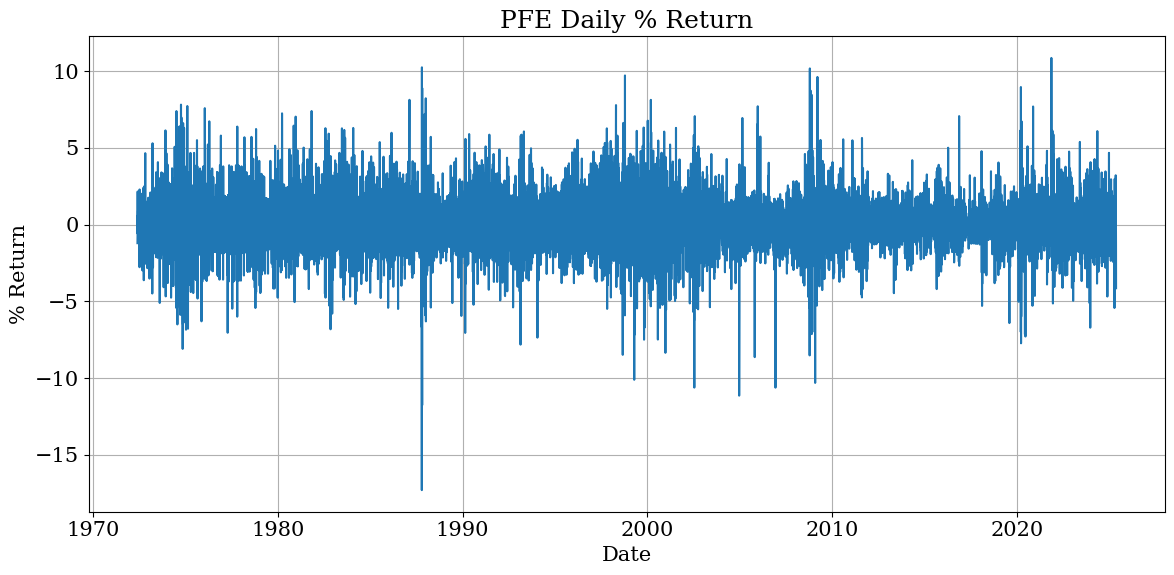

In [126]:
# Plot of return series

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='ds', y='ret')
plt.title("PFE Daily % Return")
plt.xlabel("Date")
plt.ylabel("% Return")
plt.grid(True)
plt.tight_layout()
plt.show()

In [127]:
# Summary statistics for return series

summary_stats = df['ret'].describe()
extra_stats = pd.Series({
    'skewness': df['ret'].skew(),
    'kurtosis': df['ret'].kurt()
})
summary_table = pd.concat([summary_stats, extra_stats])

print("\nSummary Statistics for PFE Return Series:\n")
print(summary_table)


Summary Statistics for PFE Return Series:

count       13343.000000
mean            0.052288
std             1.727624
min           -17.299587
25%            -0.900549
50%             0.000000
75%             0.978487
max            10.855202
skewness        0.020392
kurtosis        3.788629
dtype: float64


In [128]:
PFE_returns = df['ret'].dropna()

In [129]:
unit_root_tests(PFE_returns, "PFE return series")


=== UNIT-ROOT TESTS FOR: PFE return series ===

=== ADF Test (BIC, constant only) ===
ADF statistic: -85.1408
p-value:       0.0000
Lags used:     1
Critical values:
    1%: -3.4308
    5%: -2.8618
    10%: -2.5669
IC Best (BIC): 52309.8953

=== ADF Test (BIC, no constant) ===
ADF statistic: -85.0242
p-value:       0.0000
Lags used:     1
Critical values:
    1%: -3.4308
    5%: -2.8618
    10%: -2.5669
IC Best (BIC): 52309.8953

=== ADF Test (AIC, constant only) ===
ADF statistic: -50.2722
p-value:       0.0000
Lags used:     5
Critical values:
    1%: -3.4308
    5%: -2.8618
    10%: -2.5669
IC Best (AIC): 52278.1087

=== ADF Test (exactly 12 lags, constant only) ===
ADF statistic: -33.8068
p-value:       0.0000
Lags used:     12
Critical values:
    1%: -3.4308
    5%: -2.8618
    10%: -2.5669

=== ADF Test (BIC, constant + linear trend) ===
ADF statistic: -85.1490
p-value:       0.0000
Lags used:     1
Critical values:
    1%: -3.9594
    5%: -3.4108
    10%: -3.1272
IC Best (BIC)

/var/folders/63/8pbgtqg55qj_cy8__l6gg_bw0000gn/T/ipykernel_97272/4126655903.py:186: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




,Test,ADF stat,p-value,Lags used,IC Best,Critical values
0,"ADF (BIC, c)",-85.140750,0.0,1.0,52309.895264,1%: -3.4308; 5%: -2.8618; 10%: -2.5669
1,"ADF (BIC, nc)",-85.024214,0.0,1.0,52313.328378,1%: -2.5659; 5%: -1.9410; 10%: -1.6168
2,"ADF (AIC, c)",-50.272163,0.0,5.0,52278.108674,1%: -3.4308; 5%: -2.8618; 10%: -2.5669
3,"ADF (10 lags, c)",-33.806799,0.0,12.0,NaN,1%: -3.4308; 5%: -2.8618; 10%: -2.5669
4,"ADF (BIC, c+t)",-85.148952,0.0,1.0,52318.238269,1%: -3.9594; 5%: -3.4108; 10%: -3.1272
5,"ADF (BIC, c+t+q)",-85.173617,0.0,1.0,52324.418463,1%: -4.3720; 5%: -3.8328; 10%: -3.5535
6,Phillips–Perron (c),-115.649636,0.0,NaN,NaN,1%: -3.4308; 5%: -2.8618; 10%: -2.5669
7,KPSS (c),0.302526,0.1,23.0,NaN,10%: 0.3470; 5%: 0.4630; 2.5%: 0.5740; 1%: 0.7390


The return series fluctuates around a mean close to zero, with no visible trend, supporting the visual impression of stationarity. The summary statistics show moderate skewness and excess kurtosis, consistent with typical financial return distributions. All three statistical tests strongly support stationarity: the ADF and Phillips–Perron tests reject the null of a unit root (p-values = 0.0), while the KPSS test fails to reject the null of stationarity (stat = 0.302 < critical values at all confidence levels). Thus, we conclude the return series is stationary.

### Task 5: SACF and SPACF - Returns series

In [130]:
returns_acf_pacf = SACF_SPACF(PFE_returns)
returns_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,0.008963,0.008967,1.072207,0.300447
2,-0.046338,-0.046443,29.730633,0.000000
3,-0.019612,-0.018819,34.864542,0.000000
4,-0.017689,-0.019555,39.041628,0.000000
5,-0.006450,-0.007956,39.597040,0.000000
6,-0.020808,-0.022878,45.377594,0.000000
7,0.001889,0.000862,45.425250,0.000000
8,0.003261,0.000565,45.567211,0.000000
9,-0.010095,-0.011162,46.928175,0.000000


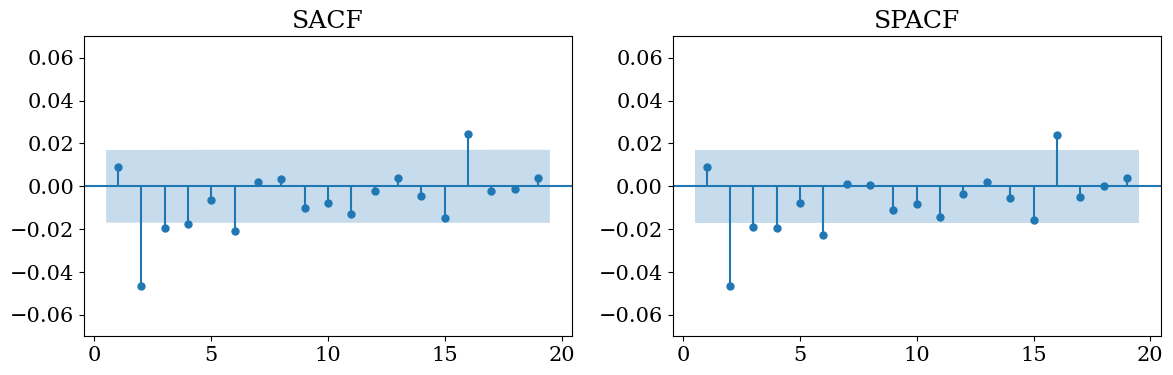

In [131]:
SACF_SPACF_plot(PFE_returns, ylim=[-0.07,0.07])

By visual inspection of the SACF and SPACF, the main feature that captures our attention if the significant spike at lag 2, as the smaller one at lag 16 is likely due to random noise, as it is isolated and not part of a consistent pattern. Both the SACF and SPACF shows such a spike at lag 2, but it is unclear whether they slowly decay to zero or are cut off after lag 2. Therefore, our proposed models are MA(2), AR(2) and ARMA(2,2), although we expect the latter to be the winner (as the correlograms show very similar behaviours overall).

### Task 6: Models estimation

In [132]:
# AR(2) estimation

ar2 = sm.tsa.statespace.SARIMAX(
    PFE_returns,
    order=(2, 0, 0),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results_ar2 = ar2.fit()
print(results_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                13343
Model:               SARIMAX(2, 0, 0)   Log Likelihood              -26209.488
Date:                Wed, 14 May 2025   AIC                          52426.976
Time:                        22:54:42   BIC                          52456.970
Sample:                             0   HQIC                         52436.985
                              - 13343                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0544      0.015      3.631      0.000       0.025       0.084
ar.L1          0.0094      0.006      1.495      0.135      -0.003       0.022
ar.L2         -0.0464      0.006     -7.649      0.0

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.



In [133]:
# MA(2) estimation

ma2 = sm.tsa.statespace.SARIMAX(
    PFE_returns,
    order=(0, 0, 2),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results_ma2 = ma2.fit()
print(results_ma2.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.



                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                13343
Model:               SARIMAX(0, 0, 2)   Log Likelihood              -26206.967
Date:                Wed, 14 May 2025   AIC                          52421.934
Time:                        22:54:43   BIC                          52451.928
Sample:                             0   HQIC                         52431.943
                              - 13343                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0523      0.014      3.628      0.000       0.024       0.080
ma.L1          0.0075      0.006      1.190      0.234      -0.005       0.020
ma.L2         -0.0479      0.006     -7.915      0.0

In [134]:
# ARMA(2,2) estimation

arma_2_2 = sm.tsa.statespace.SARIMAX(
    PFE_returns,
    order=(2, 0, 2),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results_arma_2_2 = arma_2_2.fit()
print(results_arma_2_2.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.



                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                13343
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -26199.293
Date:                Wed, 14 May 2025   AIC                          52410.586
Time:                        22:54:44   BIC                          52455.577
Sample:                             0   HQIC                         52425.599
                              - 13343                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0163      0.005      3.006      0.003       0.006       0.027
ar.L1          0.4025      0.123      3.269      0.001       0.161       0.644
ar.L2          0.2850      0.120      2.381      0.0

In [135]:
# Selecting winning model

cond_mean_model = arma_2_2
cond_mean_model_results = results_arma_2_2

All three models converged successfully. As expected and based on AIC, ARMA(2,2) performs best (AIC = 52410.582), followed by MA(2) and AR(2). In ARMA(2,2), all coefficients are statistically significant and the residual diagnostics (Ljung-Box, skewness, and kurtosis) indicate a good fit. AR(2) and MA(2) show similar structures but have slightly higher AICs and insignificant AR(1) or MA(1) terms. Therefore, ARMA(2,2) is the most adequate conditional mean model, balancing goodness of fit and parameter significance.

### Task 7: Residuals analysis

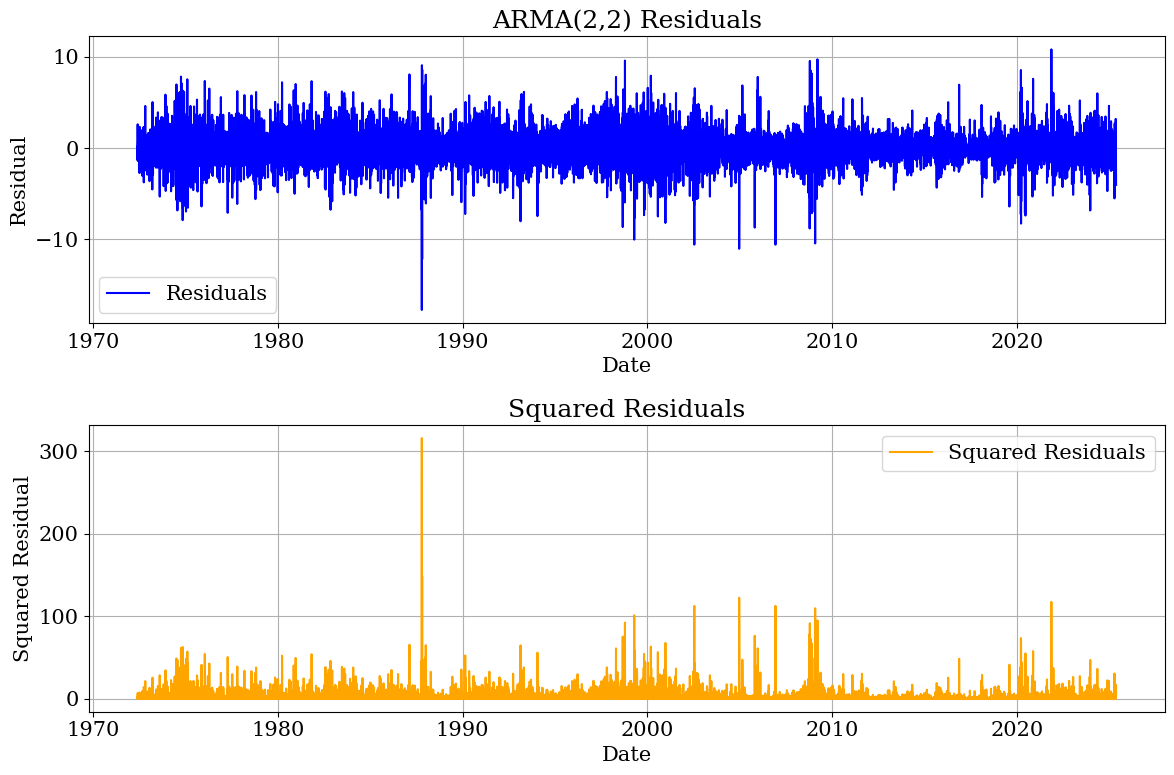

In [136]:
residuals = cond_mean_model_results.resid
squared_residuals = residuals**2
dates = df["ds"].iloc[1:]

plt.figure(figsize=(12, 8))

# Plot residuals and squared residuals
plt.subplot(2, 1, 1)
plt.plot(dates, residuals, label='Residuals', color='blue')
plt.title('ARMA(2,2) Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(dates, squared_residuals, label='Squared Residuals', color='orange')
plt.title('Squared Residuals')
plt.xlabel('Date')
plt.ylabel('Squared Residual')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [137]:
#Check for any remaning structure in the mean

residuals_acf_pacf = SACF_SPACF(residuals)
residuals_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,0.000258,0.000258,0.000890,0.976201
2,-0.000311,-0.000311,0.002179,0.998911
3,-0.003298,-0.003299,0.147320,0.985609
4,0.001540,0.001543,0.178972,0.996227
5,0.006275,0.006277,0.704602,0.982715
6,-0.010202,-0.010227,2.094229,0.910831
7,0.009425,0.009454,3.280279,0.857921
8,0.008713,0.008757,4.294074,0.829664
9,-0.005429,-0.005531,4.687605,0.860646


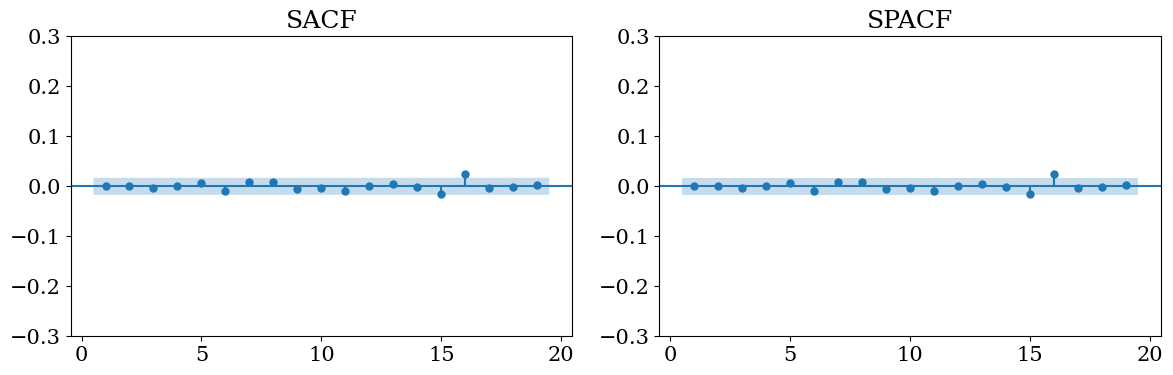

In [138]:
SACF_SPACF_plot(residuals, ylim=[-0.3,0.3])

In [139]:
#Check for any remaning structure in the variance

residuals_squared_acf_pacf = SACF_SPACF(squared_residuals)
residuals_squared_acf_pacf

,ACF,PACF,Q-stat,Q-stat Prob
Lag,,,,
1,0.155860,0.155901,324.206065,0.0
2,0.180366,0.159996,758.410657,0.0
3,0.144872,0.101327,1038.558729,0.0
4,0.115892,0.060598,1217.847115,0.0
5,0.176776,0.125646,1635.033140,0.0
6,0.125028,0.057874,1843.735458,0.0
7,0.108458,0.032828,2000.797961,0.0
8,0.113252,0.043212,2172.062519,0.0
9,0.099392,0.032394,2303.982526,0.0


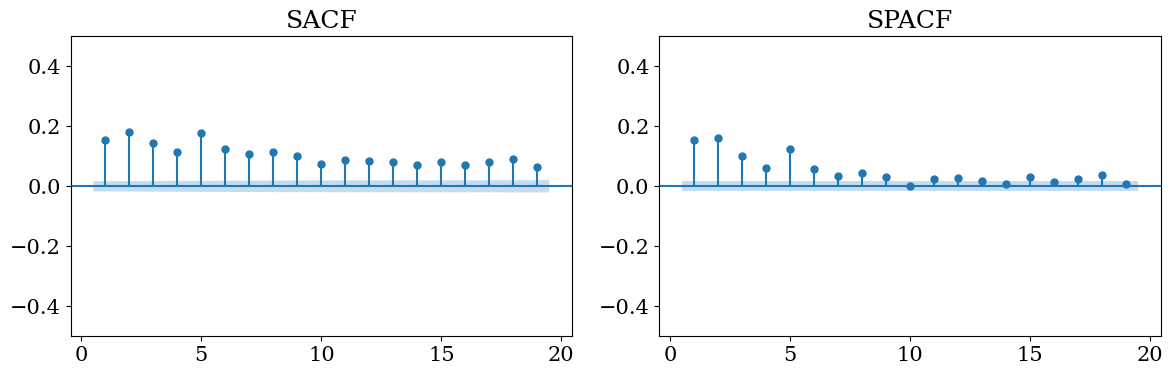

In [140]:
SACF_SPACF_plot(squared_residuals, ylim=[-0.5,0.5])

The Ljung-Box test for residuals shows no significant autocorrelation at all lags (with the p-values being equal or very close to 1 at all lags) and the plots of the SACF and SPACF confirm that there is no remaining structure in the first moment of the residuals, as their correlogram is in line with that of a white noise. As far as the squared residuals are concerned, the Ljung-Box test reveals strong autocorrelation at all lags (with all the p-values being equal to 0), and even their correlogram confirms this by showing that both the ACF and PACF have quite few lags outside the confidence band. Therefore, while there seems to be no remaining structure in the series of residuals (i.e. the first moment), indicating that the conditional mean is adequately modeled, the squared residuals display significant autocorrelation (as shown in the correlogram and confirmed by the Ljung-Box test), providing evidence of volatility clustering and the presence of conditional heteroskedasticity (ARCH effects). To capture this time-varying volatility, we must extend the model to a GARCH or ARCH framework.

### Task 8: Histogram of returns

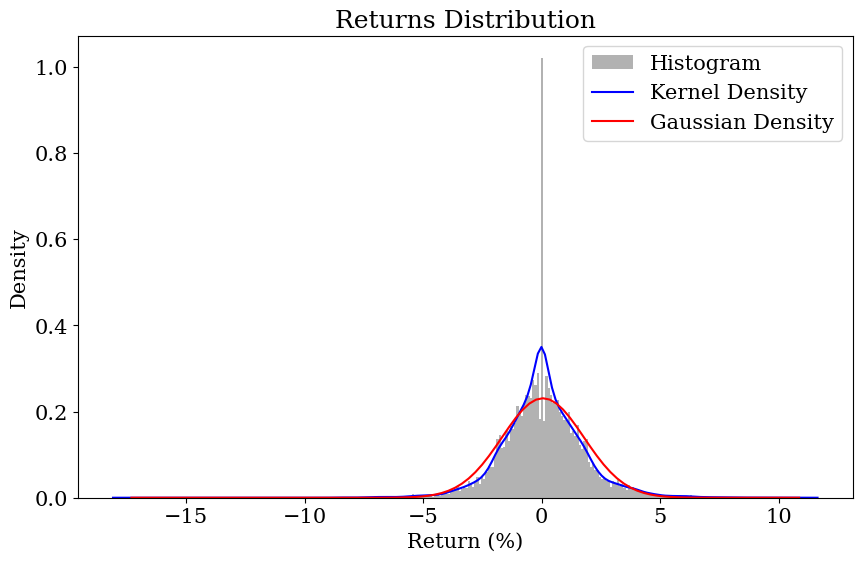

In [141]:
mean, std = PFE_returns.mean(), PFE_returns.std()
plt.figure(figsize=(10, 6))
plt.hist(PFE_returns, bins=300, density=True, color='gray', alpha=0.6, label='Histogram')
sns.kdeplot(PFE_returns, color='blue', label='Kernel Density')
x = np.linspace(min(PFE_returns), max(PFE_returns), 100)
plt.plot(x, norm.pdf(x, mean, std), 'r-', label='Gaussian Density')
plt.title('Returns Distribution')
plt.xlabel('Return (%)')
plt.ylabel('Density')
plt.legend()
plt.show()

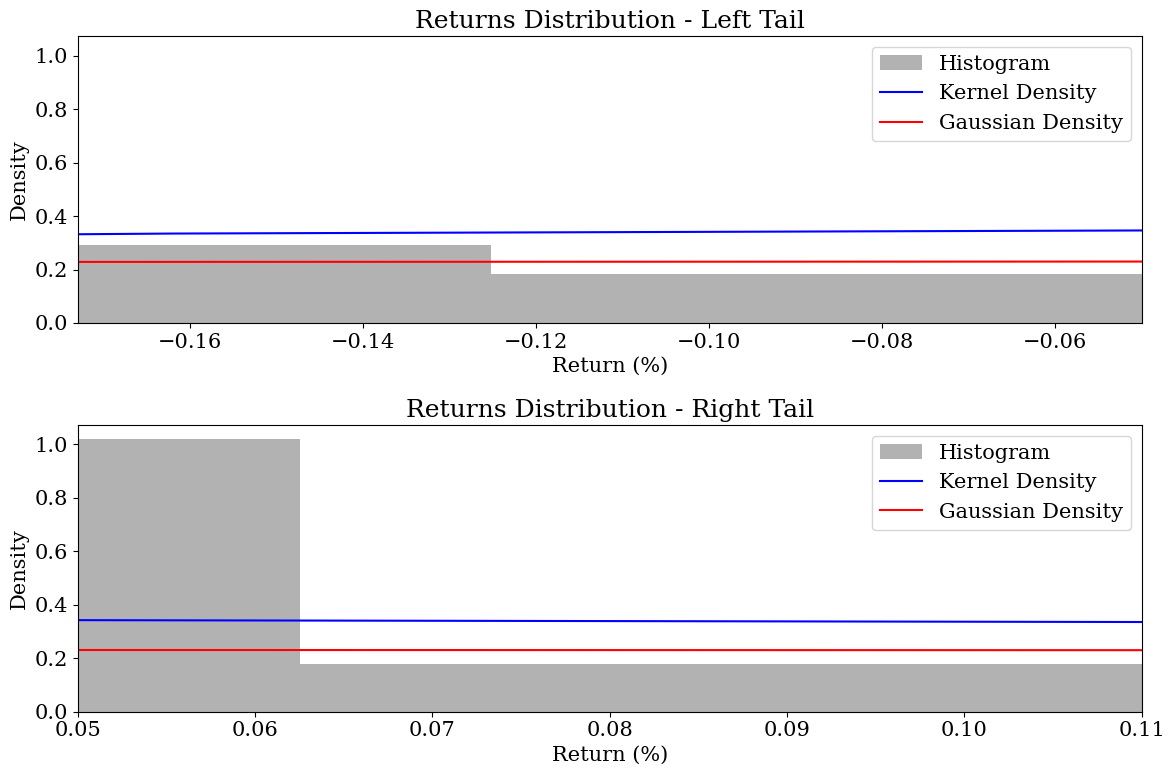

In [142]:
# Zoomed-In Version on the tails

plt.figure(figsize=(12, 8))

# Left tail
plt.subplot(2, 1, 1)
plt.hist(PFE_returns, bins=300, density=True, color='gray', alpha=0.6, label='Histogram')
sns.kdeplot(PFE_returns, color='blue', label='Kernel Density')
x = np.linspace(min(PFE_returns), max(PFE_returns), 100)
plt.plot(x, norm.pdf(x, mean, std), 'r-', label='Gaussian Density')
plt.title('Returns Distribution - Left Tail')
plt.xlabel('Return (%)')
plt.ylabel('Density')
plt.xlim(-0.173, -0.05)
plt.legend()

# Right tail
plt.subplot(2, 1, 2)
plt.hist(PFE_returns, bins=300, density=True, color='gray', alpha=0.6, label='Histogram')
sns.kdeplot(PFE_returns, color='blue', label='Kernel Density')
x = np.linspace(min(PFE_returns), max(PFE_returns), 100)
plt.plot(x, norm.pdf(x, mean, std), 'r-', label='Gaussian Density')
plt.title('Returns Distribution - Right Tail')
plt.xlabel('Return (%)')
plt.ylabel('Density')
plt.xlim(0.05, 0.11)
plt.legend()

plt.tight_layout()
plt.show()

In [143]:
# Summary statistics for return series

summary_stats = df['ret'].describe()
extra_stats = pd.Series({
    'skewness': df['ret'].skew(),
    'kurtosis': df['ret'].kurt()
})
summary_table = pd.concat([summary_stats, extra_stats])

print("\nSummary Statistics for PFE Return Series:\n")
print(summary_table)


Summary Statistics for PFE Return Series:

count       13343.000000
mean            0.052288
std             1.727624
min           -17.299587
25%            -0.900549
50%             0.000000
75%             0.978487
max            10.855202
skewness        0.020392
kurtosis        3.788629
dtype: float64


In [144]:
squared_PFE_returns = PFE_returns ** 2
cubed_PFE_returns = PFE_returns ** 3

In [145]:
fig_clustering = make_subplots(rows=1, cols=2, subplot_titles=(
    "Squared PFE Returns", "Cubed PFE Returns"))

# Squared returns
fig_clustering.add_trace(go.Scatter(
    x=dates, y=squared_PFE_returns,
    mode='lines',
    name='Squared Returns',
    line=dict(color='blue', width=1.5)
), row=1, col=1)

# Cubed returns
fig_clustering.add_trace(go.Scatter(
    x=dates, y=cubed_PFE_returns,
    mode='lines',
    name='Cubed Returns',
    line=dict(color='blue', width=1.5)
), row=1, col=2)

# Layout
fig_clustering.update_layout(
    title=dict(
        text='Transformed PFE Returns',
        x=0.5,
        font=dict(size=26, family='Serif', color='black')
    ),
    plot_bgcolor='white',

    paper_bgcolor='white',
    font=dict(
        family="Serif",
        size=18,
        color="black"
    ),
    showlegend=False,
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_clustering.update_xaxes(title_text="Date", row=1, col=1)
fig_clustering.update_yaxes(title_text="Squared Returns", row=1, col=1)

fig_clustering.update_xaxes(title_text="Date", row=1, col=2)
fig_clustering.update_yaxes(title_text="Cubed Returns", row=1, col=2)

fig_clustering.show()

The histogram of returns, overlaid with a kernel density estimate and the theoretical normal distribution, clearly shows a higher central peak and fatter tails than the Gaussian curve, indicating a leptokurtic distribution. This is further supported by the kurtosis statistic of 3.79, which exceeds the kurtosis of a standard normal distribution (3), and confirms the presence of heavy tails.

To assess volatility clustering, we examined the sample autocorrelation and partial autocorrelation functions (SACF and SPACF) of the squared residuals from an ARMA(2,2) model. The persistence of significant lags in both SACF and SPACF plots indicates serial correlation in the squared returns, a clear sign of volatility clustering. In other words, periods of high volatility tend to be followed by high volatility, and periods of calm by calm.

Additionally, the time series plots of squared and cubed returns show clear clustering of large magnitude movements over time. This temporal dependence in higher moments suggests that shocks to volatility are not isolated. Moreover, visual inspection of the cubed returns plot shows a tendency for large negative returns to be associated with stronger volatility responses than positive returns of the same magnitude. This asymmetry is indicative of the leverage effect, where negative shocks to returns lead to disproportionately higher future volatility.

The connection between leptokurticity and volatility clustering becomes evident: volatility clustering implies time-varying volatility, which increases the likelihood of extreme values on the one hand, and of more observations around the concentrated around the mean on the other, thereby contributing to the fat tails and higher peak observed in the distribution of returns.

### Task 9: EGARCH(3,2)

In [146]:
# Recall winning model

cond_mean_model = arma_2_2
cond_mean_model_results = results_arma_2_2

residuals = cond_mean_model_results.resid
squared_residuals = residuals**2

In [147]:
egarch = arch_model(
    residuals,
    mean='Zero',
    vol='EGARCH',
    p=3,
    o=1,
    q=2,
    dist='normal'
)
results_egarch = egarch.fit()
epsilons_egarch = results_egarch.resid
epsilons_egarch_squared = epsilons_egarch**2
predicted_egarch_volatility = results_egarch.conditional_volatility
predicted_egarch_variance = predicted_egarch_volatility**2
print(results_egarch.summary())

Iteration:      1,   Func. Count:      9,   Neg. LLF: 109945.90164824831
Iteration:      2,   Func. Count:     25,   Neg. LLF: 7153603264.2825775
Iteration:      3,   Func. Count:     38,   Neg. LLF: 2390415441.110918
Iteration:      4,   Func. Count:     50,   Neg. LLF: 2874672898.947195
Iteration:      5,   Func. Count:     62,   Neg. LLF: 293408057.37490916
Iteration:      6,   Func. Count:     73,   Neg. LLF: 99121.83769617658
Iteration:      7,   Func. Count:     84,   Neg. LLF: 56781.24343644963
Iteration:      8,   Func. Count:     94,   Neg. LLF: 25102.94017251234
Iteration:      9,   Func. Count:    103,   Neg. LLF: 25094.641816715874
Iteration:     10,   Func. Count:    111,   Neg. LLF: 25091.990826374597
Iteration:     11,   Func. Count:    119,   Neg. LLF: 25092.14050583369
Iteration:     12,   Func. Count:    128,   Neg. LLF: 25091.734682374525
Iteration:     13,   Func. Count:    136,   Neg. LLF: 25091.72413928402
Iteration:     14,   Func. Count:    144,   Neg. LLF: 2509

In [148]:
fig_egarch = go.Figure()

fig_egarch.add_trace(go.Scatter(
    x=df['ds'][-len(epsilons_egarch):],
    y=abs(epsilons_egarch),
    mode='lines',
    name='Absolute Residual',
    line=dict(color='steelblue', width=1.5),
    opacity=0.5
))

fig_egarch.add_trace(go.Scatter(
    x=df['ds'][-len(predicted_egarch_volatility):],
    y=predicted_egarch_volatility,
    mode='lines',
    name=f'EGARCH(3,2) Volatility',
    line=dict(color='firebrick', width=2.0)
))

fig_egarch.update_layout(
    title=dict(
        text=f'EGARCH(3,2) Predicted Volatility',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title=dict(
            text='Date',
            font=dict(size=25, family='Serif', color='black')  # Fixed titlefont
        ),
        tickfont=dict(size=20, family='Serif', color='black'),  # Adjusted for consistency
        showgrid=False
    ),
    yaxis=dict(
        title=dict(
            text='Absolute Residual / Volatility',
            font=dict(size=25, family='Serif', color='black')  # Fixed titlefont
        ),
        tickfont=dict(size=20, family='Serif', color='black'),  # Adjusted for consistency
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),
    plot_bgcolor='white',  # Changed to white
    paper_bgcolor='white',  # Changed to white
    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_egarch.show()

EGARCH(3,2) shows significant estimates for alpha[1], gamma[1], and beta[1], indicating strong persistence and asymmetric effects in volatility. The negative and significant gamma[1] confirms the presence of leverage effect. A beta[1] of 0.9858 suggests high volatility persistence. Alpha[2], alpha[3], and beta[2] are not statistically significant, which may imply overfitting or redundancy. Graphically, the conditional volatility seems to closely follow the timing of absolute residuals. However, it appears more smoothed and fails to fully capture the magnitude of extreme volatility spikes. This suggests that, despite tracking volatility dynamics, the model may not entirely reflect the intensity of movements in absolute residuals.

### Task 10: Asymmetric Power ARCH(1,2)

In [149]:
# Recall winning model

cond_mean_model = arma_2_2
cond_mean_model_results = results_arma_2_2

residuals = cond_mean_model_results.resid
squared_residuals = residuals**2

In [150]:
aparch = arch_model(residuals, mean='Zero', vol='APARCH', p=1, o=1, q=2, dist='normal')
aparch_result = aparch.fit(disp='on')
aparch_volatility = aparch_result.conditional_volatility
aparch_variance = aparch_volatility**2
print(aparch_result.summary())

Iteration:      1,   Func. Count:      8,   Neg. LLF: 28266.72282619565
Iteration:      2,   Func. Count:     21,   Neg. LLF: 37175.91323157655
Iteration:      3,   Func. Count:     30,   Neg. LLF: 26034.831694451852
Iteration:      4,   Func. Count:     38,   Neg. LLF: 109928.120897596
Iteration:      5,   Func. Count:     46,   Neg. LLF: 25525.7835435378
Iteration:      6,   Func. Count:     54,   Neg. LLF: 25099.551922688344
Iteration:      7,   Func. Count:     61,   Neg. LLF: 25230.51719742697
Iteration:      8,   Func. Count:     69,   Neg. LLF: 29332.162985990377
Iteration:      9,   Func. Count:     78,   Neg. LLF: 25549.632159276553
Iteration:     10,   Func. Count:     86,   Neg. LLF: 25091.880508153205
Iteration:     11,   Func. Count:     94,   Neg. LLF: 25210.309344509526
Iteration:     12,   Func. Count:    103,   Neg. LLF: 25096.506877455708
Iteration:     13,   Func. Count:    111,   Neg. LLF: 25091.39718751817
Iteration:     14,   Func. Count:    118,   Neg. LLF: 25091

In [151]:
# Plot absolute residuals vs conditional volatility

fig_aparch = go.Figure()

fig_aparch.add_trace(go.Scatter(
    x=df['ds'][-len(residuals):],
    y=abs(residuals),
    mode='lines',
    name='Absolute Residual',
    line=dict(color='steelblue', width=1.5),
    opacity=0.5
))

fig_aparch.add_trace(go.Scatter(
    x=df['ds'][-len(aparch_volatility):],
    y=aparch_volatility,
    mode='lines',
    name='APARCH(1,2) Volatility',
    line=dict(color='firebrick', width=2.0)
))

fig_aparch.update_layout(
    title=dict(
        text='APARCH(1,2) Predicted Volatility',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title=dict(
            text='Date',
            font=dict(size=25, family='Serif', color='black')
        ),
        tickfont=dict(size=20, family='Serif', color='black'),
        showgrid=False
    ),
    yaxis=dict(
        title=dict(
            text='Absolute Residual / Volatility',
            font=dict(size=25, family='Serif', color='black')
        ),
        tickfont=dict(size=20, family='Serif', color='black'),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_aparch.show()

The APARCH(1,2) model shows significant persistence and asymmetry in volatility. The positive and significant gamma coefficient indicates the presence of a leverage effect, where negative shocks to returns increase future volatility more than positive ones. The fitted conditional volatility series successfully tracks the evolution of the absolute residuals, confirming the model’s ability to capture time-varying volatility. Moreover, the estimated power term (δ ≠ 2) allows for flexibility beyond the standard GARCH framework. Overall, the model captures both volatility clustering and asymmetric responses to shocks, offering an improvement over symmetric models.

### Task 11: Comparison of the two models

In [152]:
# Recall winning model for conditional mean

cond_mean_model = arma_2_2
cond_mean_model_results = results_arma_2_2

residuals = cond_mean_model_results.resid
squared_residuals = residuals**2

In [153]:
ic_comparison = pd.DataFrame({
    'Model': ['EGARCH(3,2)', 'APARCH(1,2)'],
    'AIC': [results_egarch.aic, aparch_result.aic],
    'BIC': [results_egarch.bic, aparch_result.bic],
    'Log-Likelihood': [results_egarch.loglikelihood, aparch_result.loglikelihood]
})

print("Model Comparison (ICs and Log-Likelihood):")
print(ic_comparison)

Model Comparison (ICs and Log-Likelihood):
         Model           AIC           BIC  Log-Likelihood
0  EGARCH(3,2)  50197.446397  50249.937627   -25091.723198
1  APARCH(1,2)  50194.781945  50239.774429   -25091.390973


In [154]:
# Testing Egarch (3,2)

pred_df = pd.DataFrame(PFE_returns)
pred_df.rename(columns={pred_df.columns[0]: "Returns"}, inplace=True)

pred_df["Residual"] = residuals
pred_df["Residual Squared"] = squared_residuals
pred_df["Predicted variance EGARCH(3,2)"] = predicted_egarch_variance

pred_df.dropna(inplace=True)
pred_df.head()

,Returns,Residual,Residual Squared,"Predicted variance EGARCH(3,2)"
1,-1.212032,-1.212032,1.469022,1.426791
2,-0.306691,0.164826,0.027167,1.553372
3,2.153788,2.606421,6.793428,1.381489
4,0.000000,-0.795699,0.633138,1.692084
5,-0.602500,-1.397360,1.952616,1.770885


In [155]:
Y = pred_df['Residual Squared']
X = pred_df['Predicted variance EGARCH(3,2)']
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
results=model
test=dict()
test["Predicted variance EGARCH(3,2)"] = {
            'summary': results.summary().as_text(),
            'f_test': None,
            't_test': None
        }
try:
  f_test = results.f_test(f"const = 0, Predicted variance EGARCH(3,2) = 1")
  test["Predicted variance EGARCH(3,2)"]['f_test'] = f_test
except Exception as e:
  test["Predicted variance EGARCH(3,2)"]['f_test'] = f"Error performing F-test: {e}"

try:
  t_test = results.t_test(f"Predicted variance EGARCH(3,2) = 1")
  test["Predicted variance EGARCH(3,2)"]['t_test'] = t_test
except Exception as e:
  test["Predicted variance EGARCH(3,2)"]['t_test'] = f"Error performing T-test: {e}"

print(test["Predicted variance EGARCH(3,2)"]['summary'])
print("\nF-test for hypothesis that intercept = 0 and coefficient of regressor = 1:")
print(test["Predicted variance EGARCH(3,2)"]['f_test'])
print("\nT-test for hypothesis that the coefficient of regressor = 1:")
print(test["Predicted variance EGARCH(3,2)"]['t_test'])

                            OLS Regression Results                            
Dep. Variable:       Residual Squared   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     1222.
Date:                Wed, 14 May 2025   Prob (F-statistic):          3.14e-256
Time:                        22:54:47   Log-Likelihood:                -44650.
No. Observations:               13343   AIC:                         8.930e+04
Df Residuals:                   13341   BIC:                         8.932e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [156]:
# Testing APARCH(1,2)

pred_df = pd.DataFrame(PFE_returns)
pred_df.rename(columns={pred_df.columns[0]: "Returns"}, inplace=True)

pred_df["Residual"] = residuals
pred_df["Residual Squared"] = squared_residuals
pred_df["Predicted variance APARCH(1,2)"] = aparch_variance

pred_df.dropna(inplace=True)
pred_df.head()

,Returns,Residual,Residual Squared,"Predicted variance APARCH(1,2)"
1,-1.212032,-1.212032,1.469022,1.456580
2,-0.306691,0.164826,0.027167,1.546694
3,2.153788,2.606421,6.793428,1.418609
4,0.000000,-0.795699,0.633138,1.703408
5,-0.602500,-1.397360,1.952616,1.630933


In [157]:
Y = pred_df['Residual Squared']
X = pred_df['Predicted variance APARCH(1,2)']
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
results=model
test=dict()
test["Predicted variance APARCH(1,2)"] = {
            'summary': results.summary().as_text(),
            'f_test': None,
            't_test': None
        }
try:
  f_test = results.f_test(f"const = 0, Predicted variance APARCH(1,2) = 1")
  test["Predicted variance APARCH(1,2)"]['f_test'] = f_test
except Exception as e:
  test["Predicted variance APARCH(1,2)"]['f_test'] = f"Error performing F-test: {e}"

try:
  t_test = results.t_test(f"Predicted variance APARCH(1,2) = 1")
  test["Predicted variance APARCH(1,2)"]['t_test'] = t_test
except Exception as e:
  test["Predicted variance APARCH(1,2)"]['t_test'] = f"Error performing T-test: {e}"

print(test["Predicted variance APARCH(1,2)"]['summary'])
print("\nF-test for hypothesis that intercept = 0 and coefficient of regressor = 1:")
print(test["Predicted variance APARCH(1,2)"]['f_test'])
print("\nT-test for hypothesis that the coefficient of regressor = 1:")
print(test["Predicted variance APARCH(1,2)"]['t_test'])

                            OLS Regression Results                            
Dep. Variable:       Residual Squared   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     1223.
Date:                Wed, 14 May 2025   Prob (F-statistic):          2.34e-256
Time:                        22:54:47   Log-Likelihood:                -44650.
No. Observations:               13343   AIC:                         8.930e+04
Df Residuals:                   13341   BIC:                         8.932e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [158]:
# Selecting winning model for conditional variance

cond_var_model = aparch
cond_var_model_results = aparch_result

Both models have nearly identical log-likelihoods, but the APARCH(1,2) model slightly outperforms EGARCH(3,2) having both a lower AIC and lower BIC, suggesting a marginally better in-sample fit.

In the auxiliary regressions testing for unbiasedness and efficiency, the EGARCH(3,2) model showed a statistically significant deviation from the null (F-test p = 0.0266), indicating that the filtered variance is not a perfect unbiased and efficient predictor. The APARCH(1,2) model, however, had a higher p-value in the F-test (p = 0.065), meaning we fail to reject the null at the 5% level, thus suggesting that it more closely satisfies the efficiency and unbiasedness condition.

Overall, while both models explain a modest 8.4% of the variation in squared residuals (R² = 0.084), APARCH(1,2) wins due to its slightly better ICs and its more favorable performance in the auxiliary regression.

### Task 12: Splitting between train and test

In [159]:
# Summary of winning models for conditional mean and variance

cond_mean_model = arma_2_2
cond_mean_model_results = results_arma_2_2

cond_var_model = aparch
cond_var_model_results = aparch_result

In [160]:
split_idx = int(len(PFE_returns) * 0.8)

train_val = PFE_returns[:split_idx]
test = PFE_returns[split_idx:]

print(f"Train/Validation size: {len(train_val)}")
print(f"Test size: {len(test)}")

Train/Validation size: 10674
Test size: 2669


Using the ARMA(2,2) model estimated on the entire dataset and then evaluating it on a holdout set drawn from that same dataset gives the traditional time series model an unfair advantage. This is because the model’s parameters have been informed by the entire return series, including data from the test set. As a result, the test set is no longer a truly independent evaluation sample, which can lead to overly optimistic performance assessments. In contrast, machine learning models will be trained only on the 80% training set and tested on the remaining 20%, meaning they will be evaluated on genuinely unseen data. This asymmetry in information usage creates an imbalance in the comparison. For a fair horserace, all models should be estimated and validated strictly on the training portion only, ensuring that the test set remains completely out-of-sample. Ignoring this would bias the comparison in favor of the ARMA-APARCH specification.

### Task 13: Out-of-sample forecast exercise with cond_mean_model and cond_var_model

In [161]:
'''
#Fit  on training data
arma_model = SARIMAX(
    train_val,
    order=(2, 0, 2),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)
arma_results = arma_model.fit(disp=False)
'''
# model parameters
params = cond_mean_model_results.params
c = params['intercept']
phi1 = params.get('ar.L1', 0)
phi2 = params.get('ar.L2', 0)
theta1 = params.get('ma.L1', 0)
theta2 = params.get('ma.L2', 0)


r_tm1 = train_val.iloc[-1]
r_tm2 = train_val.iloc[-2]
resid_tm1 = cond_mean_model_results.resid.iloc[split_idx-1]
resid_tm2 = cond_mean_model_results.resid.iloc[split_idx-2]


rolling_forecasts = []
true_returns = []
oos_resid = []

for i in range(len(test)):
    
    r_hat = c + phi1 * r_tm1 + phi2 * r_tm2 + theta1 * resid_tm1 + theta2 * resid_tm2
    rolling_forecasts.append(r_hat)

    r_true = test.iloc[i]
    true_returns.append(r_true)
    resid_new = r_true - r_hat
    oos_resid.append(resid_new)

    r_tm2, r_tm1 = r_tm1, r_true
    resid_tm2, resid_tm1 = resid_tm1, resid_new

rolling_forecasts = np.array(rolling_forecasts)
true_returns = np.array(true_returns)
msfe_fixed_recursive = mean_squared_error(true_returns, rolling_forecasts)

print(f"Fixed-coefficient Recursive ARMA(2,2) MSFE: {msfe_fixed_recursive:.6f}")


Fixed-coefficient Recursive ARMA(2,2) MSFE: 2.137937


In [162]:
import plotly.graph_objects as go

# Time index for test set
test_dates = df['ds'].iloc[split_idx:]

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test_dates,
    y=rolling_forecasts,
    mode='lines',
    name='Forecasted Returns (ARMA Rec Fixed Coeffs)',
    line=dict(color='firebrick', width=2)
))

fig.add_trace(go.Scatter(
    x=test_dates,
    y=true_returns,
    mode='lines',
    name='Actual Returns',
    line=dict(color='steelblue', width=1.5),
    opacity=0.6
))

fig.update_layout(
    title=dict(
        text='Out-of-Sample Forecast: ARMA(2,2) Recursively Forecasted vs Actual Returns',
        x=0.5,
        font=dict(size=22, family='Serif', color='black')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title='Date',
        title_font=dict(size=18, family='Serif', color='black'),
        tickfont=dict(size=14),
        showgrid=False
    ),
    yaxis=dict(
        title='Return',
        title_font=dict(size=18, family='Serif', color='black'),
        tickfont=dict(size=14),
        showgrid=True
    ),
    legend=dict(
        font=dict(size=14)
    )
)

fig.show()


In [163]:
'''
# retrain the aparch model with only the train set 

residuals = arma_results.resid

squared_residuals = residuals**2
aparch = arch_model(residuals, mean='Zero', vol='APARCH', p=1, o=1, q=2, dist='normal')
aparch_result = aparch.fit(disp='on')
aparch_volatility = aparch_result.conditional_volatility
aparch_variance = aparch_volatility**2
print(aparch_result.summary())
'''

"\n# retrain the aparch model with only the train set \n\nresiduals = arma_results.resid\n\nsquared_residuals = residuals**2\naparch = arch_model(residuals, mean='Zero', vol='APARCH', p=1, o=1, q=2, dist='normal')\naparch_result = aparch.fit(disp='on')\naparch_volatility = aparch_result.conditional_volatility\naparch_variance = aparch_volatility**2\nprint(aparch_result.summary())\n"

In [164]:
'''
omega = aparch_result.params['omega']
alpha = aparch_result.params['alpha[1]']
gamma = aparch_result.params['gamma[1]']
beta_1 = aparch_result.params['beta[1]']
beta_2 = aparch_result.params['beta[2]']
delta = aparch_result.params['delta']
'''

"\nomega = aparch_result.params['omega']\nalpha = aparch_result.params['alpha[1]']\ngamma = aparch_result.params['gamma[1]']\nbeta_1 = aparch_result.params['beta[1]']\nbeta_2 = aparch_result.params['beta[2]']\ndelta = aparch_result.params['delta']\n"

In [165]:

omega = cond_var_model_results.params['omega']
alpha = cond_var_model_results.params['alpha[1]']
gamma = cond_var_model_results.params['gamma[1]']
beta_1 = cond_var_model_results.params['beta[1]']
beta_2 = cond_var_model_results.params['beta[2]']
delta = cond_var_model_results.params['delta']


In [166]:
'''
train_val_residuals = residuals #here we use the residuals from the arma trained on the 80% only
#train_val_residuals = cond_mean_model_results.resid[:split_idx]
holdout_residuals = cond_mean_model_results.resid[split_idx:] #we test against the residuals of the model trained on 100%

# Get full conditional volatility series (from in-sample model)
volatility_series = cond_var_model_results.conditional_volatility
sigma_delta_train = volatility_series[:split_idx] ** delta
'''


'\ntrain_val_residuals = residuals #here we use the residuals from the arma trained on the 80% only\n#train_val_residuals = cond_mean_model_results.resid[:split_idx]\nholdout_residuals = cond_mean_model_results.resid[split_idx:] #we test against the residuals of the model trained on 100%\n\n# Get full conditional volatility series (from in-sample model)\nvolatility_series = cond_var_model_results.conditional_volatility\nsigma_delta_train = volatility_series[:split_idx] ** delta\n'

In [167]:
train_val_residuals = cond_mean_model_results.resid[:split_idx]
holdout_residuals = cond_mean_model_results.resid[split_idx:]

volatility_series = cond_var_model_results.conditional_volatility
sigma_delta_train = volatility_series[:split_idx] ** delta

In [168]:
# Initialize array
oos_forecast_aparch = np.zeros(len(holdout_residuals))

# Convert to numpy arrays
resids = np.array(holdout_residuals)

# Get last two in-sample conditional variances and residuals
sigma_t_1 = sigma_delta_train.iloc[-1]
sigma_t_2 = sigma_delta_train.iloc[-2]
resid_t_1 = train_val_residuals.iloc[-1]
resid_t_2 = train_val_residuals.iloc[-2]

# Forecast t = 0
term_1 = abs(resid_t_1) - gamma * resid_t_1
oos_forecast_aparch[0] = omega + alpha * (term_1 ** delta) + beta_1 * sigma_t_1 + beta_2 * sigma_t_2

# Forecast t = 1
term_2 = abs(resids[0]) - gamma * resids[0]
oos_forecast_aparch[1] = omega + alpha * (term_2 ** delta) + beta_1 * oos_forecast_aparch[0] + beta_2 * sigma_t_1

# Recursive forecast for t ≥ 2
for t in range(2, len(holdout_residuals)):
    resid_prev = resids[t - 1]
    sigma_prev_1 = oos_forecast_aparch[t - 1]
    sigma_prev_2 = oos_forecast_aparch[t - 2]

    term = abs(resid_prev) - gamma * resid_prev
    oos_forecast_aparch[t] = omega + alpha * (term ** delta) + beta_1 * sigma_prev_1 + beta_2 * sigma_prev_2

oos_vol_forecast_aparch = oos_forecast_aparch ** (1/delta)


In [186]:
import plotly.graph_objects as go

# Time index for test set
test_dates = df['ds'].iloc[split_idx:]

# Create interactive plot
fig = go.Figure()

#plot the vol forecasts from the model trained on train set only (80%)
fig.add_trace(go.Scatter(
    x=test_dates,
    y=oos_vol_forecast_aparch, 
    mode='lines',
    name='Forecasted Volatility (APARCH(1,2))',
    line=dict(color='firebrick', width=2)
))

#plot the holdout residuals from the arma trained on 100% data
fig.add_trace(go.Scatter(
    x=test_dates,
    y=abs(resids),
    mode='lines',
    name='Absolute Residuals (ARMA(2,2))',
    line=dict(color='steelblue', width=1.5),
    opacity=0.6
))

fig.update_layout(
    title=dict(
        text='Out-of-Sample Forecast: APARCH(1,2) vs Squared Residuals',
        x=0.5,
        font=dict(size=22, family='Serif', color='black')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title='Date',
        title_font=dict(size=18, family='Serif', color='black'),
        tickfont=dict(size=14),
        showgrid=False
    ),
    yaxis=dict(
        title='Variance / Squared Residual',
        title_font=dict(size=18, family='Serif', color='black'),
        tickfont=dict(size=14),
        showgrid=True
    ),
    legend=dict(
        font=dict(size=14)
    )
)

fig.show()


In [170]:
msfe_aparch = mean_squared_error(holdout_residuals**2, oos_vol_forecast_aparch**2) 
print(f"APARCH(1,2) Out-of-sample MSFE: {msfe_aparch:.6f}")


APARCH(1,2) Out-of-sample MSFE: 27.756370


In [171]:
errors_fixed_aparch = (holdout_residuals)**2 - (oos_vol_forecast_aparch)**2
RMSFE_fixed_aparch = np.sqrt(np.mean(np.array(errors_fixed_aparch)**2))
RMSFE_fixed_aparch

np.float64(5.268431448580413)

The APARCH(1,2) model performs reasonably well out-of-sample, with an MSFE of 27.76. Although the in-sample plot (Task 10) showed that the model captured volatility clustering effectively, the forecast appears slightly smoother and slower to respond to extreme shocks. Still, it successfully tracks major volatility shifts and replicates the general structure seen in-sample. The in-sample and out-of-sample results are consistent, confirming that the model generalizes the underlying volatility dynamics well.

### Task 14: Machine Learning Model

In [172]:
import_path = "MktTbill_daily.xlsx"
Tbill = pd.read_excel(import_path)

Tbill['ds'] = pd.to_datetime(Tbill['Unnamed: 0'], format='%Y%m%d')
Tbill.drop(columns=['Unnamed: 0'], inplace=True)

# Shift Mkt-RF and RF forward by one day to avoid data leakage
Tbill['Mkt-RF_lag1'] = Tbill['Mkt-RF'].shift(1)
Tbill['RF_lag1'] = Tbill['RF'].shift(1)

Tbill.dropna(inplace=True)

Tbill.head()


,Mkt-RF,RF,ds,Mkt-RF_lag1,RF_lag1
1,0.45,0.009,1926-07-02,0.10,0.009
2,0.17,0.009,1926-07-06,0.45,0.009
3,0.09,0.009,1926-07-07,0.17,0.009
4,0.21,0.009,1926-07-08,0.09,0.009
5,-0.71,0.009,1926-07-09,0.21,0.009


In [173]:
ticker = ['PFE']
end_date = '2025-05-07'

df = yf.download(
    ticker,
    interval="1d",
    progress=False,
    end=end_date
)
df = df.loc[:, (['Close'], ticker)]
df.columns = df.columns.droplevel()
df = df.reset_index()
df = df.rename(columns={
    'Date': 'ds',
    'PFE': 'price'
})
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)
df.columns.name = 'Ticker'
df.columns.name = None
df = df.rename_axis(columns=None)
df['ret'] = df['price'].pct_change()*100
df.head()

,ds,price,ret
0,1972-06-01,0.153657,NaN
1,1972-06-02,0.151795,-1.212032
2,1972-06-05,0.151329,-0.306691
3,1972-06-06,0.154589,2.153788
4,1972-06-07,0.154589,0.000000


In [174]:

def binary_encoding(vars_to_encode=10):

    # Calculate the number of binary digits needed
    num_bits = int(np.ceil(np.log2(vars_to_encode)))
    col_names = [f'binary_{i+1}' for i in range(num_bits)]

    # Generate all possible binary combinations
    all_combinations = list(itertools.product([0, 1], repeat=num_bits))

    # Keep only the last `vars_to_encode` rows
    relevant_combinations = all_combinations[-vars_to_encode:]

    return pd.DataFrame(relevant_combinations, columns=col_names)


In [175]:
df['ret_lag1'] = df['ret'].shift(1)
df['ret_lag2'] = df['ret'].shift(2)
df['ret_lag3'] = df['ret'].shift(3)

df['dayofweek'] = df['ds'].dt.dayofweek
df['dayofmonth'] = df['ds'].dt.day

dow_dummies = pd.get_dummies(df['dayofweek'], prefix='dow')

unique_days = sorted(df['dayofmonth'].unique())

# Generate binary encoding for each day of the month (1,2,3, etc.)
day_encoding = binary_encoding(len(unique_days))
day_encoding.index = unique_days
day_encoding.columns = [f'dom_{bit}' for bit in range(day_encoding.shape[1])]

df = pd.concat([df, dow_dummies, day_encoding], axis=1)
df['ds'] = pd.to_datetime(df['ds'])

df = df.merge(Tbill[['ds', 'Mkt-RF_lag1', 'RF_lag1']], on='ds', how='left')
df.head()



,ds,price,ret,ret_lag1,ret_lag2,ret_lag3,dayofweek,dayofmonth,dow_0,dow_1,dow_2,dow_3,dow_4,dom_0,dom_1,dom_2,dom_3,dom_4,Mkt-RF_lag1,RF_lag1
0,1972-06-01,0.153657,NaN,NaN,NaN,NaN,3,1,False,False,False,True,False,NaN,NaN,NaN,NaN,NaN,-0.73,0.014
1,1972-06-02,0.151795,-1.212032,NaN,NaN,NaN,4,2,False,False,False,False,True,0.0,0.0,0.0,0.0,1.0,0.22,0.013
2,1972-06-05,0.151329,-0.306691,-1.212032,NaN,NaN,0,5,True,False,False,False,False,0.0,0.0,0.0,1.0,0.0,0.11,0.013
3,1972-06-06,0.154589,2.153788,-0.306691,-1.212032,NaN,1,6,False,True,False,False,False,0.0,0.0,0.0,1.0,1.0,-0.80,0.013
4,1972-06-07,0.154589,0.000000,2.153788,-0.306691,-1.212032,2,7,False,False,True,False,False,0.0,0.0,1.0,0.0,0.0,-0.56,0.013


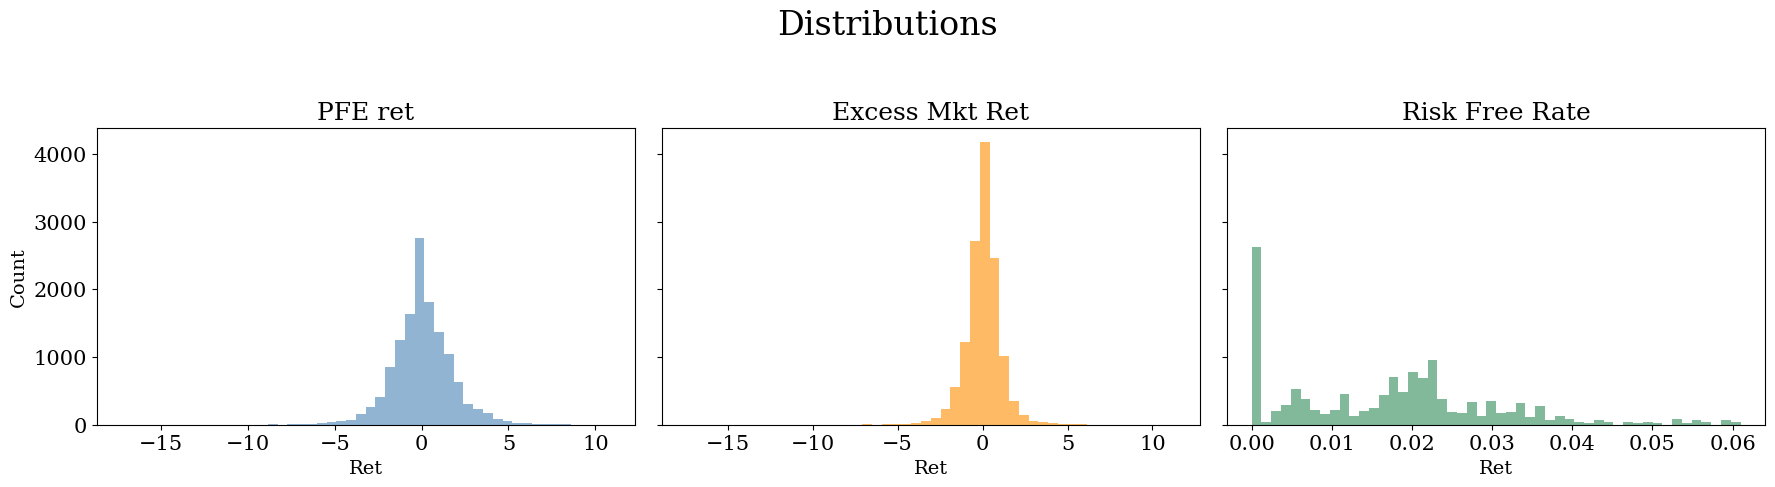

In [176]:
features = ['ret', 'Mkt-RF_lag1', 'RF_lag1']
titles = ['PFE ret', 'Excess Mkt Ret', 'Risk Free Rate']
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Distributions', fontsize=24, fontfamily='serif')

for ax, feature, title, color in zip(axes, features, titles, colors):
    ax.hist(df[feature], bins=50, alpha=0.6, color=color)
    ax.set_title(title, fontsize=18, fontfamily='serif')
    ax.set_xlabel('Ret', fontsize=14, fontfamily='serif')
    ax.grid(False)

axes[0].set_ylabel('Count', fontsize=14, fontfamily='serif')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [177]:
'''
df_model = df.dropna(subset=['ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'Mkt-RF_lag1', 'RF_lag1'])
print(df_model.info())

split_idx = int(len(df_model) * 0.8)
train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

X_cols = ['ret_lag1', 'ret_lag2', 'ret_lag3', 'Mkt-RF_lag1', 'RF_lag1'] + \
         [col for col in df_model.columns if 'dow_' in col or 'dom_' in col]

X_train = train[X_cols]
y_train = train['ret']
X_test = test[X_cols]
y_test = test['ret']
'''


"\ndf_model = df.dropna(subset=['ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'Mkt-RF_lag1', 'RF_lag1'])\nprint(df_model.info())\n\nsplit_idx = int(len(df_model) * 0.8)\ntrain = df_model.iloc[:split_idx]\ntest = df_model.iloc[split_idx:]\n\nX_cols = ['ret_lag1', 'ret_lag2', 'ret_lag3', 'Mkt-RF_lag1', 'RF_lag1'] +          [col for col in df_model.columns if 'dow_' in col or 'dom_' in col]\n\nX_train = train[X_cols]\ny_train = train['ret']\nX_test = test[X_cols]\ny_test = test['ret']\n"

In [178]:
'''
#not needed for decision tree, but might be helpful for other models
scaler = StandardScaler() # - mean and /std
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cond_mean_model_ML = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
cond_mean_model_ML.fit(X_train_scaled, y_train)
cond_mean_model_ML_predictions = cond_mean_model_ML.predict(X_test_scaled)
'''

'\n#not needed for decision tree, but might be helpful for other models\nscaler = StandardScaler() # - mean and /std\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n\ncond_mean_model_ML = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)\ncond_mean_model_ML.fit(X_train_scaled, y_train)\ncond_mean_model_ML_predictions = cond_mean_model_ML.predict(X_test_scaled)\n'

In [179]:
df_model = df.dropna(subset=['ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'Mkt-RF_lag1', 'RF_lag1'])

X_cols = ['ret_lag1', 'ret_lag2', 'ret_lag3', 'Mkt-RF_lag1', 'RF_lag1'] + \
         [col for col in df_model.columns if 'dow_' in col or 'dom_' in col]
X = df_model[X_cols]
y = df_model['ret']

split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale features, not needed for decision tree, but could be helpful if we try different models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tscv = TimeSeriesSplit(n_splits=5)
best_score = float('inf')
best_params = None

for depth in [3, 5, 10]:
    for min_split in [10, 50, 100]:
        fold_scores = []
        for train_idx, val_idx in tscv.split(X_train_scaled):
            X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = DecisionTreeRegressor(max_depth=depth, min_samples_split=min_split, random_state=42)
            model.fit(X_fold_train, y_fold_train)
            preds = model.predict(X_fold_val)
            fold_scores.append(mean_squared_error(y_fold_val, preds))

        avg_score = np.mean(fold_scores)
        if avg_score < best_score:
            best_score = avg_score
            best_params = (depth, min_split)

print("Best parameters:", best_params)

# final model with best parameters
cond_mean_model_ML = DecisionTreeRegressor(
    max_depth=best_params[0],
    min_samples_split=best_params[1],
    random_state=42
)
cond_mean_model_ML.fit(X_train_scaled, y_train)
cond_mean_model_ML_predictions = cond_mean_model_ML.predict(X_test_scaled)


Best parameters: (3, 10)


We selected a Decision Tree Regressor for its interpretability, nonlinearity, and ease of use without requiring feature scaling. The model was trained on 80% of the sample. Features included lagged returns (up to lag 3) to capture autoregressive structure, binary-encoded day-of-week dummies, and a binary-encoded transformation of the day-of-month to capture calendar anomalies. Additionally, we merged in macroeconomic features from the MktTbill dataset: the excess market return and the 30-day Treasury bill rate, both shifted to prevent lookahead bias. While scaling isn’t strictly necessary for trees, we applied it to maintain consistency and allow flexibility for future model extensions. We chose not to further transform the macro features, as their distributions were already informative and well-behaved: returns were centered and symmetric, while interest rates exhibited natural right skew. No evidence of severe outliers or scale imbalances was observed, making additional transformation unnecessary for the learning algorithm.

Hyperparameters were selected using 5-fold time series cross-validation on the training set. We performed a grid search over multiple values of max_depth and min_samples_split, minimizing the mean squared forecast error across validation folds. This approach allows for model selection that balances complexity and generalization while respecting the temporal ordering of the data — essential in time series contexts to prevent leakage.

### Task 15: Visual and numerical inspection

In [180]:
msfe_arma = mean_squared_error(y_test, cond_mean_model_results.forecast(steps = len(y_test)))
msfe_ml = mean_squared_error(y_test, cond_mean_model_ML_predictions)

print(f"ARMA Model (cond_mean_model) MSFE: {msfe_arma:.6f}")
print(f"Machine Learning Model (cond_mean_model_ML) MSFE: {msfe_ml:.6f}")

ARMA Model (cond_mean_model) MSFE: 2.073109
Machine Learning Model (cond_mean_model_ML) MSFE: 2.113188


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [181]:
import plotly.graph_objects as go

# Time index for test set
test_dates = df['ds'].iloc[split_idx:]

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test_dates,
    y=cond_mean_model_ML_predictions,
    mode='lines',
    name='Forecasted Returns (ML Model)',
    line=dict(color='firebrick', width=2)
))

fig.add_trace(go.Scatter(
    x=test_dates,
    y=y_test.values,
    mode='lines',
    name='Actual Returns',
    line=dict(color='steelblue', width=1.5),
    opacity=0.6
))

fig.update_layout(
    title=dict(
        text='Out-of-Sample Forecast: ML Model vs Actual Returns',
        x=0.5,
        font=dict(size=22, family='Serif', color='black')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title='Date',
        title_font=dict(size=18, family='Serif', color='black'),
        tickfont=dict(size=14),
        showgrid=False
    ),
    yaxis=dict(
        title='Return',
        title_font=dict(size=18, family='Serif', color='black'),
        tickfont=dict(size=14),
        showgrid=True
    ),
    legend=dict(
        font=dict(size=14)
    )
)

fig.show()

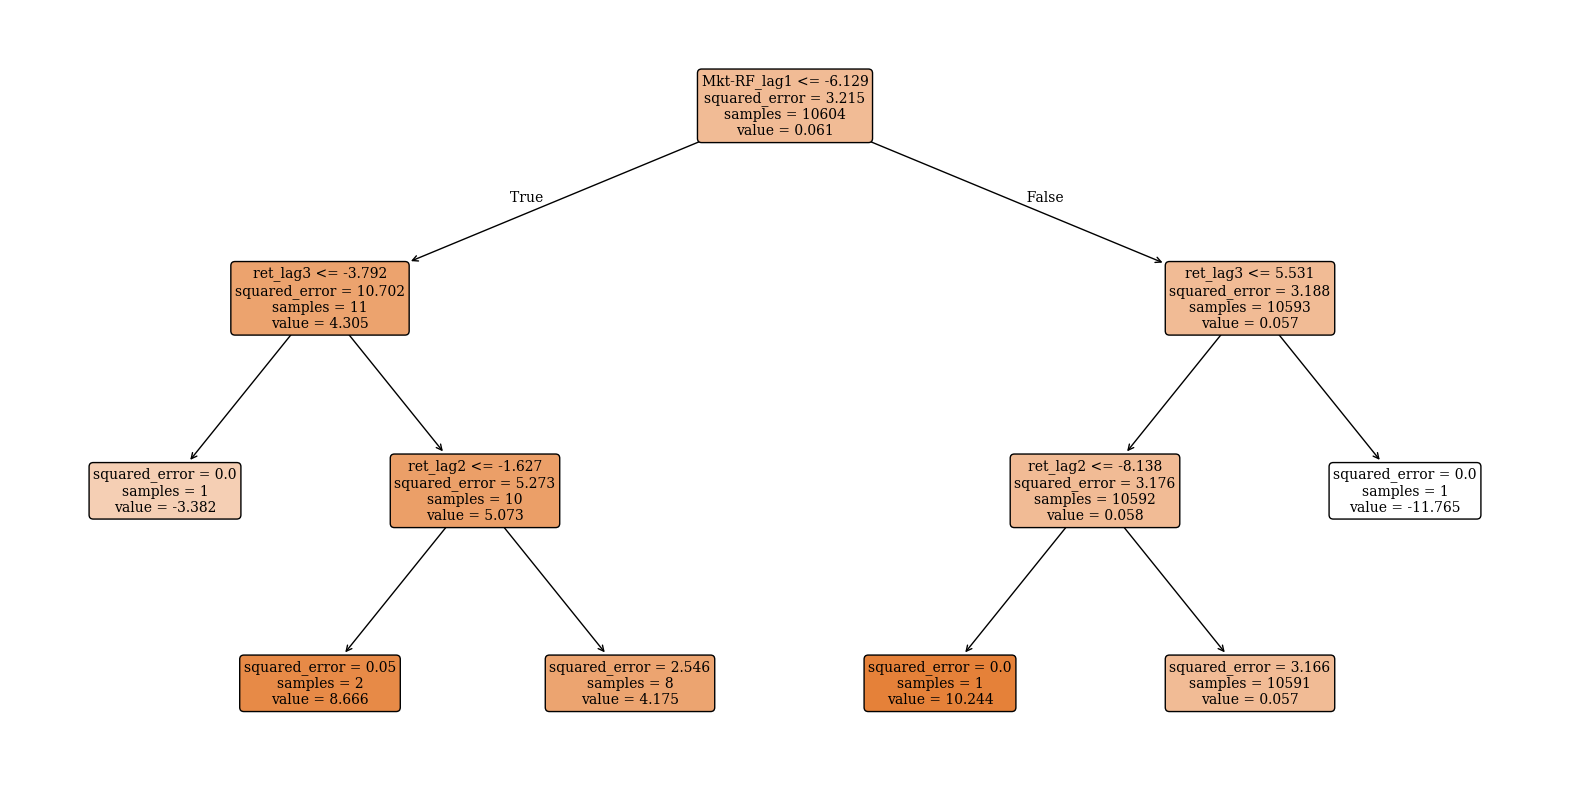

In [182]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    cond_mean_model_ML,
    feature_names=X_cols,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [183]:
print(pd.Series(
    cond_mean_model_ML.feature_importances_,
    index=X_cols
))

ret_lag1       0.000000
ret_lag2       0.252331
ret_lag3       0.379806
Mkt-RF_lag1    0.367863
RF_lag1        0.000000
dow_0          0.000000
dow_1          0.000000
dow_2          0.000000
dow_3          0.000000
dow_4          0.000000
dom_0          0.000000
dom_1          0.000000
dom_2          0.000000
dom_3          0.000000
dom_4          0.000000
dtype: float64


The ML model performed slightly worse than the ARMA benchmark, with an MSFE of 2.11 compared to 2.07. Visually, its forecasts were nearly flat and failed to capture any meaningful variation in returns. Feature importance reveals the model ignored calendar effects and relied almost entirely on just three features: ret_lag2, ret_lag3, and Mkt-RF_lag1. This heavy reliance, coupled with over-regularization, led to underfitting and poor generalization. The tree’s inability to leverage additional information or adapt to changing dynamics explains the lack of responsiveness in the forecast, despite its theoretically more flexible structure.

### Task 16: Reflections:

The results we observed were in line with expectations. As discussed in Task 12, the ARMA model was initially trained on the entire dataset, while the machine learning model was trained only on the 80% training set. This gave the ARMA model indirect access to future information, likely contributing to its slightly better performance. To ensure a completely fair evaluation, I would revise our approach by estimating the mean model only on the training data and using those residuals to fit the volatility model. This would prevent any use of future data in the prediction pipeline and maintain full out-of-sample integrity.

We selected the ARMA(2,2) model because it performed best on the full dataset, but this choice may not hold if selection were restricted to the training period. A different model might be more appropriate under a strict out-of-sample regime.

Reflecting on the model architectures: ARMA(2,2) is well-suited for capturing short-term autocorrelation in returns and is relatively robust when signal is limited. APARCH(1,2), on the other hand, is capable of modeling asymmetric volatility clustering and showed strong in- and out-of-sample alignment. The Decision Tree Regressor, while theoretically flexible, failed to capture much signal. Its simplicity, combined with regularization and lack of sequential memory, likely led to underfitting. It relied heavily on a few features and ignored others completely, such as calendar variables.

Overall, classical econometric models proved more effective in this context, though more sophisticated ML architectures or hybrid approaches may yield better results in future work.

In [184]:
'''
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 4. Grid search with cross-validation
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='neg_mean_squared_error',
                           verbose=1)

grid_search.fit(X_train_scaled, y_train)

# 5. Best model
best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# 6. Predict and evaluate
y_pred = best_rf.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test R² Score: {r2:.4f}")

# 7. Feature importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()
'''

'\nrf = RandomForestRegressor(random_state=42)\n\nparam_grid = {\n    \'n_estimators\': [100, 200],\n    \'max_depth\': [3, 5, 10, None],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4]\n}\n\n# 4. Grid search with cross-validation\ngrid_search = GridSearchCV(estimator=rf,\n                           param_grid=param_grid,\n                           cv=5,\n                           n_jobs=-1,\n                           scoring=\'neg_mean_squared_error\',\n                           verbose=1)\n\ngrid_search.fit(X_train_scaled, y_train)\n\n# 5. Best model\nbest_rf = grid_search.best_estimator_\nprint("Best parameters:", grid_search.best_params_)\n\n# 6. Predict and evaluate\ny_pred = best_rf.predict(X_test_scaled)\n\nmse = mean_squared_error(y_test, y_pred)\nr2 = r2_score(y_test, y_pred)\n\nprint(f"Test MSE: {mse:.4f}")\nprint(f"Test R² Score: {r2:.4f}")\n\n# 7. Feature importance\nimportances = best_rf.feature_importances_\nindices = np.argsort(importance

In [185]:
'''
# Time index for test set
test_dates = df['ds'].iloc[split_idx:]

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test_dates,
    y=y_pred,
    mode='lines',
    name='Forecasted Returns (ML Model)',
    line=dict(color='firebrick', width=2)
))

fig.add_trace(go.Scatter(
    x=test_dates,
    y=y_test.values,
    mode='lines',
    name='Actual Returns',
    line=dict(color='steelblue', width=1.5),
    opacity=0.6
))

fig.update_layout(
    title=dict(
        text='Out-of-Sample Forecast: ML Model vs Actual Returns',
        x=0.5,
        font=dict(size=22, family='Serif', color='black')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title='Date',
        title_font=dict(size=18, family='Serif', color='black'),
        tickfont=dict(size=14),
        showgrid=False
    ),
    yaxis=dict(
        title='Return',
        title_font=dict(size=18, family='Serif', color='black'),
        tickfont=dict(size=14),
        showgrid=True
    ),
    legend=dict(
        font=dict(size=14)
    )
)

fig.show()
'''

"\n# Time index for test set\ntest_dates = df['ds'].iloc[split_idx:]\n\n# Create interactive plot\nfig = go.Figure()\n\nfig.add_trace(go.Scatter(\n    x=test_dates,\n    y=y_pred,\n    mode='lines',\n    name='Forecasted Returns (ML Model)',\n    line=dict(color='firebrick', width=2)\n))\n\nfig.add_trace(go.Scatter(\n    x=test_dates,\n    y=y_test.values,\n    mode='lines',\n    name='Actual Returns',\n    line=dict(color='steelblue', width=1.5),\n    opacity=0.6\n))\n\nfig.update_layout(\n    title=dict(\n        text='Out-of-Sample Forecast: ML Model vs Actual Returns',\n        x=0.5,\n        font=dict(size=22, family='Serif', color='black')\n    ),\n    plot_bgcolor='white',\n    paper_bgcolor='white',\n    xaxis=dict(\n        title='Date',\n        title_font=dict(size=18, family='Serif', color='black'),\n        tickfont=dict(size=14),\n        showgrid=False\n    ),\n    yaxis=dict(\n        title='Return',\n        title_font=dict(size=18, family='Serif', color='black'),\n  